In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

data = pd.read_csv("data.csv")

# reduce size for speed
data = data.sample(5000, random_state=42)

print(data.head())

            FILENAME                                                URL  \
136221    827598.txt                          https://www.northcm.ac.th   
56609   oph00308.txt  https://unitedmartialartscenters.com/at0/mygov...   
46393    8112660.txt  https://email.mail1.onesignal.os.tc/c/ejwcz02u...   
129746   8135291.txt                                http://uqr.to/1il1z   
131464    586561.txt               https://www.woolworthsrewards.com.au   

        URLLength                        Domain  DomainLength  IsDomainIP  \
136221         24             www.northcm.ac.th            17           0   
56609          59  unitedmartialartscenters.com            28           0   
46393         385   email.mail1.onesignal.os.tc            27           0   
129746         19                        uqr.to             6           0   
131464         35  www.woolworthsrewards.com.au            28           0   

        TLD  URLSimilarityIndex  CharContinuationRate  TLDLegitimateProb  ...  \
13622

In [2]:
print("Shape:", data.shape)
print("Missing:", data.isnull().sum().sum())

Shape: (5000, 56)
Missing: 0


In [3]:
data.fillna(data.mean(numeric_only=True), inplace=True)

for col in data.select_dtypes('object'):
    data[col] = LabelEncoder().fit_transform(data[col])

# CHANGE 'label' if needed
X = data.drop('label', axis=1)
y = data['label']

print("Preprocessing Done")

Preprocessing Done


In [4]:
X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

model = Ridge(alpha=1)
model.fit(X_train, y_train)

# Simple validation
y_pred = model.predict(X_test)
mse_simple = mean_squared_error(y_test, y_pred)

# k-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
mse_cv = -cv_scores.mean()

print("Simple MSE:", mse_simple)
print("Cross-Validation MSE:", mse_cv)

Simple MSE: 0.012453844290603968
Cross-Validation MSE: 0.013542106317403027


Best Alpha: 0.1


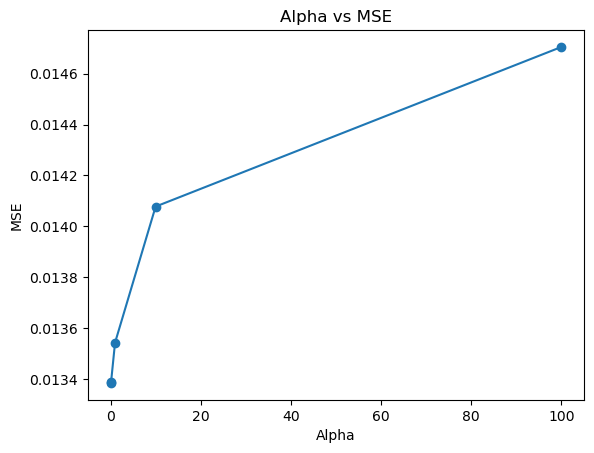

In [5]:
alphas = [0.01, 0.1, 1, 10, 100]
mse_list = []

for a in alphas:
    model = Ridge(alpha=a)
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
    mse_list.append(-scores.mean())

print("Best Alpha:", alphas[np.argmin(mse_list)])

# Graph: Alpha vs MSE
plt.plot(alphas, mse_list, marker='o')
plt.title("Alpha vs MSE")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.show()